In [1]:
import os
import copy
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [3]:
BASE_DIR = Path("..")

DATASET_DIR = BASE_DIR / "dataset"

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"

SPLITS_DIR = BASE_DIR / "splits"

MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Models:", MODELS_DIR)

Train: ../dataset/train
Validation: ../dataset/val
Models: ../models


In [4]:
NUM_CLASSES = 7

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = 4

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 25

PATIENCE = 5

print("Configuration loaded.")

Configuration loaded.


In [5]:
train_transform = transforms.Compose([
    
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    
    transforms.RandomHorizontalFlip(p=0.5),
    
    transforms.RandomVerticalFlip(p=0.5),
    
    transforms.RandomRotation(degrees=20),
    
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.05
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
val_transform = transforms.Compose([
    
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))

print("\nClasses:")
print(train_dataset.classes)

assert len(train_dataset) == 8017
assert len(val_dataset) == 1998
assert train_dataset.class_to_idx == val_dataset.class_to_idx

Train images: 8017
Validation images: 1998

Classes:
['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [8]:
PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 251
Validation batches: 63


Class Weights
↓
DenseNet121
↓
Loss + Optimizer + Scheduler
↓
Training Function
↓
Validation Function
↓
Training Loop
↓
Early Stopping
↓
Save Best Model
↓
Restore Best Model
↓
Save History
↓
Generate Graphs
↓
Final Summary

Class order:
['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Class weights:
tensor([ 4.4564,  2.7798,  1.2854, 13.3173,  1.2868,  0.2134, 10.0464],
       device='cuda:0')

Model classifier:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1024, out_features=7, bias=True)
)

Model device:
cuda:0

STARTING DENSENET121 TRAINING

Epoch [1/25]
Time: 51.9 seconds
-----------------------------------------------------------------
Train Loss: 1.2090
Train Accuracy: 0.5723
Train Balanced Accuracy: 0.5591
Train Macro F1: 0.4011
-----------------------------------------------------------------
Validation Loss: 1.0221
Validation Accuracy: 0.6371
Validation Balanced Accuracy: 0.6463
Validation Macro F1: 0.4960
-----------------------------------------------------------------
Learning Rate: 0.000100

✓ BEST MODEL SAVED
Best Validation Macro F1: 0.4960

Epoch [2/25]
Time: 51.7 seconds
-----------------------------------------------------------------
Train Loss: 0.7894
Tr

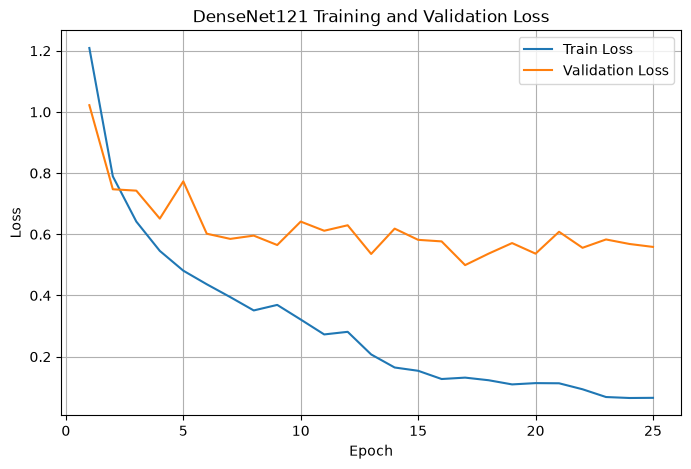

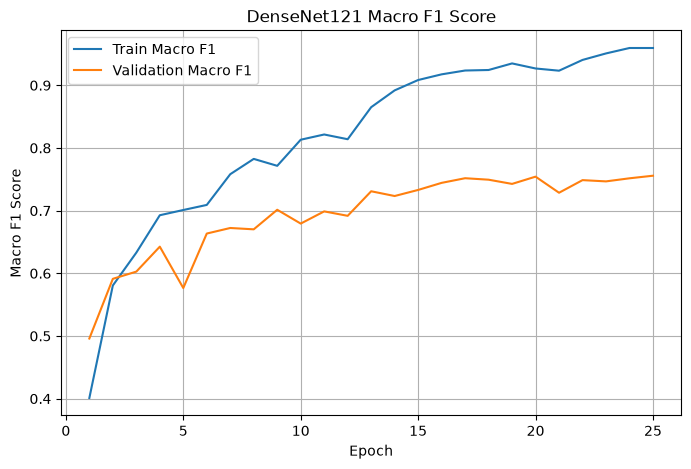

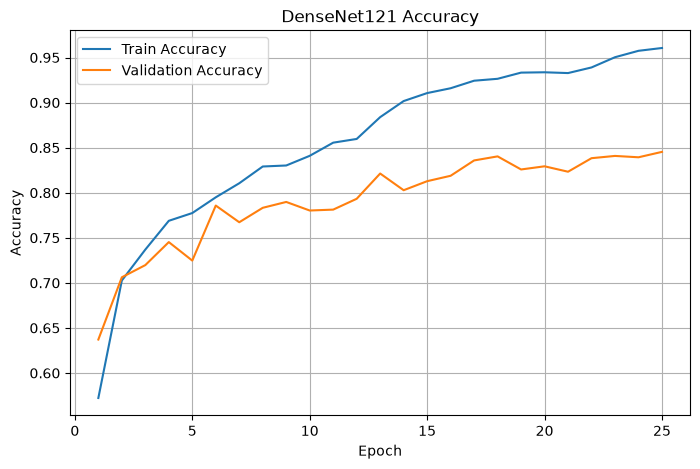


PHASE 12 COMPLETED SUCCESSFULLY
Epochs completed: 25
Best Validation Macro F1: 0.7557
Final Validation Accuracy: 0.8453
Final Validation Balanced Accuracy: 0.7659

Best model saved at:
../models/densenet121_baseline_best.pth

Training history saved at:
../models/densenet121_baseline_history.csv


In [9]:
# ============================================================
# PHASE 12: COMPLETE MODEL SETUP, TRAINING & EVALUATION
# ============================================================

import copy
import time

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)


# ============================================================
# STEP 8: LOAD AND ALIGN CLASS WEIGHTS
# ============================================================

weights_df = pd.read_csv(
    SPLITS_DIR / "class_weights.csv"
)

weights_df = (
    weights_df
    .set_index("Class")
    .loc[train_dataset.classes]
    .reset_index()
)

class_weights = torch.tensor(
    weights_df["Class_Weight"].values,
    dtype=torch.float32
).to(device)

print("Class order:")
print(train_dataset.classes)

print("\nClass weights:")
print(class_weights)


# ============================================================
# STEP 9: BUILD PRETRAINED DENSENET121
# ============================================================

model = models.densenet121(
    weights=models.DenseNet121_Weights.DEFAULT
)

num_features = model.classifier.in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, NUM_CLASSES)
)

model = model.to(device)

print("\nModel classifier:")
print(model.classifier)

print("\nModel device:")
print(next(model.parameters()).device)


# ============================================================
# STEP 10: LOSS, OPTIMIZER AND SCHEDULER
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


# ============================================================
# STEP 11: TRAINING FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    all_predictions = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_balanced_accuracy = balanced_accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_balanced_accuracy,
        epoch_f1
    )


# ============================================================
# STEP 12: VALIDATION FUNCTION
# ============================================================

def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_balanced_accuracy = balanced_accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_balanced_accuracy,
        epoch_f1,
        all_labels,
        all_predictions
    )


# ============================================================
# STEP 13: TRAINING HISTORY AND EARLY STOPPING
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],

    "train_accuracy": [],
    "val_accuracy": [],

    "train_balanced_accuracy": [],
    "val_balanced_accuracy": [],

    "train_f1": [],
    "val_f1": [],

    "learning_rate": []
}

best_val_f1 = -float("inf")

best_model_state = None

epochs_without_improvement = 0

BEST_MODEL_PATH = (
    MODELS_DIR / "densenet121_baseline_best.pth"
)


# ============================================================
# STEP 14: FULL TRAINING LOOP
# ============================================================

print("\n" + "=" * 65)
print("STARTING DENSENET121 TRAINING")
print("=" * 65)


for epoch in range(MAX_EPOCHS):

    start_time = time.time()


    # ---------------- TRAIN ----------------

    (
        train_loss,
        train_acc,
        train_bal_acc,
        train_f1
    ) = train_one_epoch(

        model,
        train_loader,
        criterion,
        optimizer,
        device
    )


    # ---------------- VALIDATION ----------------

    (
        val_loss,
        val_acc,
        val_bal_acc,
        val_f1,
        val_labels,
        val_predictions

    ) = validate(

        model,
        val_loader,
        criterion,
        device
    )


    # ---------------- SCHEDULER ----------------

    scheduler.step(val_f1)

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # ---------------- SAVE HISTORY ----------------

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    history["train_balanced_accuracy"].append(
        train_bal_acc
    )

    history["val_balanced_accuracy"].append(
        val_bal_acc
    )

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    history["learning_rate"].append(current_lr)


    # ---------------- PRINT RESULTS ----------------

    epoch_time = time.time() - start_time

    print("\n" + "=" * 65)

    print(
        f"Epoch [{epoch + 1}/{MAX_EPOCHS}]"
    )

    print(
        f"Time: {epoch_time:.1f} seconds"
    )

    print("-" * 65)

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: {train_acc:.4f}"
    )

    print(
        f"Train Balanced Accuracy: "
        f"{train_bal_acc:.4f}"
    )

    print(
        f"Train Macro F1: {train_f1:.4f}"
    )

    print("-" * 65)

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: {val_acc:.4f}"
    )

    print(
        f"Validation Balanced Accuracy: "
        f"{val_bal_acc:.4f}"
    )

    print(
        f"Validation Macro F1: {val_f1:.4f}"
    )

    print("-" * 65)

    print(
        f"Learning Rate: {current_lr:.6f}"
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_state,
            BEST_MODEL_PATH
        )

        epochs_without_improvement = 0

        print(
            f"\n✓ BEST MODEL SAVED"
        )

        print(
            f"Best Validation Macro F1: "
            f"{best_val_f1:.4f}"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"\nNo improvement: "
            f"{epochs_without_improvement}/{PATIENCE}"
        )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if epochs_without_improvement >= PATIENCE:

        print(
            "\nEARLY STOPPING TRIGGERED"
        )

        break


# ============================================================
# STEP 15: RESTORE BEST MODEL
# ============================================================

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)

print("\n" + "=" * 65)
print("BEST MODEL RESTORED")
print("=" * 65)

print(
    f"Best Validation Macro F1: "
    f"{best_val_f1:.4f}"
)


# ============================================================
# STEP 16: SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(history)

HISTORY_PATH = (
    MODELS_DIR /
    "densenet121_baseline_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

print(
    f"\nTraining history saved to:\n"
    f"{HISTORY_PATH}"
)


# ============================================================
# STEP 17: PLOT LOSS
# ============================================================

epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "DenseNet121 Training and Validation Loss"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# STEP 18: PLOT MACRO F1
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_f1"],
    label="Train Macro F1"
)

plt.plot(
    epochs,
    history["val_f1"],
    label="Validation Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1 Score")

plt.title(
    "DenseNet121 Macro F1 Score"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# STEP 19: PLOT ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "DenseNet121 Accuracy"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# STEP 20: FINAL SUMMARY
# ============================================================

print("\n" + "=" * 65)
print("PHASE 12 COMPLETED SUCCESSFULLY")
print("=" * 65)

print(
    f"Epochs completed: "
    f"{len(history['train_loss'])}"
)

print(
    f"Best Validation Macro F1: "
    f"{best_val_f1:.4f}"
)

print(
    f"Final Validation Accuracy: "
    f"{history['val_accuracy'][-1]:.4f}"
)

print(
    f"Final Validation Balanced Accuracy: "
    f"{history['val_balanced_accuracy'][-1]:.4f}"
)

print(
    f"\nBest model saved at:\n"
    f"{BEST_MODEL_PATH}"
)

print(
    f"\nTraining history saved at:\n"
    f"{HISTORY_PATH}"
)